In [1]:
import matplotlib.pyplot as plt
import numpy as np
import cvxpy as cp

from safety_formation.formation import Agent,Topology
from safety_formation.control_law.nominal import CentralizedFormationControl


## Topology

<Axes: title={'center': 'Topology (Leader=0, Followers=1..N)'}>

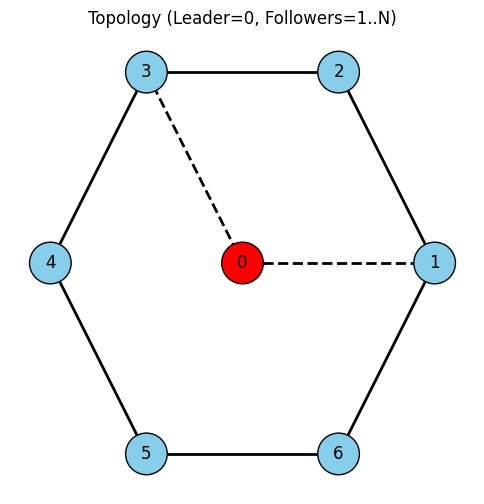

In [2]:
adj_matrix = np.array([
    [0, 1, 0, 0, 0, 1],
    [1, 0, 1, 0, 0, 0],
    [0, 1, 0, 1, 0, 0],
    [0, 0, 1, 0, 1, 0],
    [0, 0, 0, 1, 0, 1],
    [1, 0, 0, 0, 1, 0],
], dtype=float)

# adj_matrix = np.ones(6) - np.eye(6)

leader_access = [1, 0, 1, 0, 0, 0]

topo = Topology(num_agents=6, adjacency_matrix=adj_matrix, leader_access=leader_access)

topo.plot()

## Agent creation

In [3]:
# Define formation offsets (f_i) for each follower
f1 = [1, 0, 0, 0]
f2 = [1/2, np.sqrt(3)/2, 0, 0]
f3 = [-1/2, np.sqrt(3)/2, 0, 0]
f4 = [-1, 0, 0, 0]
f5 = [-1/2, -np.sqrt(3)/2, 0, 0]
f6 = [1/2, -np.sqrt(3)/2, 0, 0]

f_list = [f1, f2, f3, f4, f5, f6]

print(np.array(f_list)[:,:2])
print("\n")

# Agent creation (N = 6)
N = 6

# Initial states (x0) for each agent: [x, y, vx, vy]
x0_0 = [0, 0, 0.5, 0]
x1_0 = [-2, 0, -0.5, 0]
x2_0 = [0, 2, 0.2, -0.2]
x3_0 = [0, 1, 1, 0]
x4_0 = [2, 2, 0, 0]
x5_0 = [0, -2, 0, 1]
x6_0 = [2, -2, 0.3, 0]

xi_0_list = [x0_0, x1_0, x2_0, x3_0, x4_0, x5_0, x6_0]

leader = Agent(agent_id=0, x0=x0_0, f_target=[0, 0, 0, 0])  # Leader has no formation offset
agents = []
for i in range(N):
    agents.append(Agent(agent_id=i+1, x0=xi_0_list[i+1], f_target=f_list[i], alpha = 12))

for agent in agents:
    print(f"Agent {agent.id} Initial state: \n {agent.state}, \n Formation offset: \n {agent.f} \n")

[[ 1.         0.       ]
 [ 0.5        0.8660254]
 [-0.5        0.8660254]
 [-1.         0.       ]
 [-0.5       -0.8660254]
 [ 0.5       -0.8660254]]


Agent 1 Initial state: 
 [[-2. ]
 [ 0. ]
 [-0.5]
 [ 0. ]], 
 Formation offset: 
 [[1.]
 [0.]
 [0.]
 [0.]] 

Agent 2 Initial state: 
 [[ 0. ]
 [ 2. ]
 [ 0.2]
 [-0.2]], 
 Formation offset: 
 [[0.5      ]
 [0.8660254]
 [0.       ]
 [0.       ]] 

Agent 3 Initial state: 
 [[0.]
 [1.]
 [1.]
 [0.]], 
 Formation offset: 
 [[-0.5      ]
 [ 0.8660254]
 [ 0.       ]
 [ 0.       ]] 

Agent 4 Initial state: 
 [[2.]
 [2.]
 [0.]
 [0.]], 
 Formation offset: 
 [[-1.]
 [ 0.]
 [ 0.]
 [ 0.]] 

Agent 5 Initial state: 
 [[ 0.]
 [-2.]
 [ 0.]
 [ 1.]], 
 Formation offset: 
 [[-0.5      ]
 [-0.8660254]
 [ 0.       ]
 [ 0.       ]] 

Agent 6 Initial state: 
 [[ 2. ]
 [-2. ]
 [ 0.3]
 [ 0. ]], 
 Formation offset: 
 [[ 0.5      ]
 [-0.8660254]
 [ 0.       ]
 [ 0.       ]] 



## Gain Calculation

In [4]:
# 1. Load System Matrices
A = np.array(leader.A)
B = np.array(leader.B)
n = A.shape[0]

# 2. Compute the coupling strength threshold (delta)
# delta corresponds to the smallest real eigenvalue of the Augmented Laplacian matrix
H = topo.get_augmented_laplacian()  # shape: (N x N)
delta = np.min(np.real(np.linalg.eigvals(H)))

# 3. Define the optimization variable
# Q = inv(P). We use a symmetric variable to represent the Lyapunov candidate
Q = cp.Variable((n, n), symmetric=True)

# 4. Formulate the Linear Matrix Inequality (LMI)
# Based on the Schur Complement of the algebraic Riccati-like inequality
# term1: A*Q + Q*A' - 2*delta*B*B'
term1 = A @ Q + Q @ A.T - 2 * delta * B @ B.T

# Construct the block matrix for the LMI
LMI_block = cp.bmat([
    [term1,                  Q],
    [Q,      -np.eye(n) / delta]
])

# Define constraints:
# 1. The block matrix must be negative definite (LMI << 0)
# 2. Q must be positive definite (Q >> 0)
# We use a small epsilon (1e-6) to enforce strict inequality
constraints = [
    LMI_block << -1e-6 * np.eye(2 * n),
    Q >> 1e-6 * np.eye(n)
]

# 5. Define the Problem and Solve
# Optimization Goal: Minimize trace(Q) to prevent the solver from 
# finding unnecessarily large values (regularization).
prob = cp.Problem(cp.Minimize(0), constraints) 

# CVXOPT is generally more accurate for small-to-medium LMI problems than SCS
prob.solve(solver=cp.CVXOPT, verbose=True)

# 6. Extract results and compute Gain Matrix K
if prob.status == cp.OPTIMAL:
    Q_val = Q.value
    P = np.linalg.inv(Q_val)
    # The control gain is derived from the Lyapunov matrix P
    K = B.T @ P 
    print("Feedback Gain Matrix K:\n", K)
else:
    print("LMI infeasible. Please check system stabilizability or delta value.")

(CVXPY) Mar 04 03:47:51 PM: Your problem has 16 variables, 80 constraints, and 0 parameters.
(CVXPY) Mar 04 03:47:51 PM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Mar 04 03:47:51 PM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) Mar 04 03:47:51 PM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Mar 04 03:47:51 PM: Your problem is compiled with the CPP canonicalization backend.
(CVXPY) Mar 04 03:47:51 PM: Compiling problem (target solver=CVXOPT).
(CVXPY) Mar 04 03:47:51 PM: Reduction chain: Dcp2Cone -> CvxAttr2Constr -> ConeMatrixStuffing -> CVXOPT
(CVXPY) Mar 04 03:47:51 PM: Applying reduction Dcp2Cone
(CVXPY) Mar 04 03:47:51 PM: Applying reduction CvxAttr2Constr
(CVXPY) Mar 04 03:47:51 PM: Applying reduction ConeMatrixStuffing
(CVXPY) Mar 04 03:47:51 PM: Applying reduction CVXOPT
(CVXPY) Mar 04 03:47:51 PM: Finished problem compilation (t

                                     CVXPY                                     
                                     v1.8.1                                    
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------
-------------------------------------------------------------------------------
                                Numerical solver                               
-------------------------------------------------------------------------------
     pcost       dcost       gap    pres   dres   k/t
 0:  0.0000e+00 -1.7407e+01  3e+01  4e-01  3e+00  1e+00
 1:  0.0000e+00 -7.4724e-01  1e+00  2e-02  2e-01  7e-02
 2:  0.0000e+00 -1.1798e-02  1e-02  3e-04  2e-03  1e-03
 3:  0.0000e+00 -1.1780e-04  1e-04  3e-06  2e-05  1e-05
 4:  0.0000e+00 -1.1780e-06  1e-06  3e-08  2e-07  1e-07
 5:  0.0000e+00 -1.1780e-0

In [5]:
K_prime = np.zeros_like(K)  # No leader feedforward in this example
K = np.array([
        [1.6978, -0.0004, 3.9308, 0.0005],
        [0.0002, 1.6966, 0.0005, 3.9309],
    ], dtype=float)

## Simulation

In [6]:
from utils import ErrorTracker, compute_delta_norms
from utils import plot_formation_error, plot_relative_trajectories, plot_world_trajectories

controller = CentralizedFormationControl(K_matrix=K, K_prime_matrix=K_prime)
tracker = ErrorTracker()

dt = 0.01
T = 10.0
steps = int(T / dt)

for k in range(steps):

    # ---- Controller (centralized) ----
    U = controller.compute_nominal(
        all_agents=agents,
        topology=topo,
        leader_state=leader.state
    )  # shape (N,2)

    # ---- Apply control to each follower ----
    for i, ag in enumerate(agents):
        ag.update_physics(U[i], dt)

    # ---- Leader dynamics (optional) ----
    # Ví dụ leader constant velocity:
    leader.update_physics([0, 0], dt)

    # ---- Track error ----
    tracker.step(agents, leader.state)

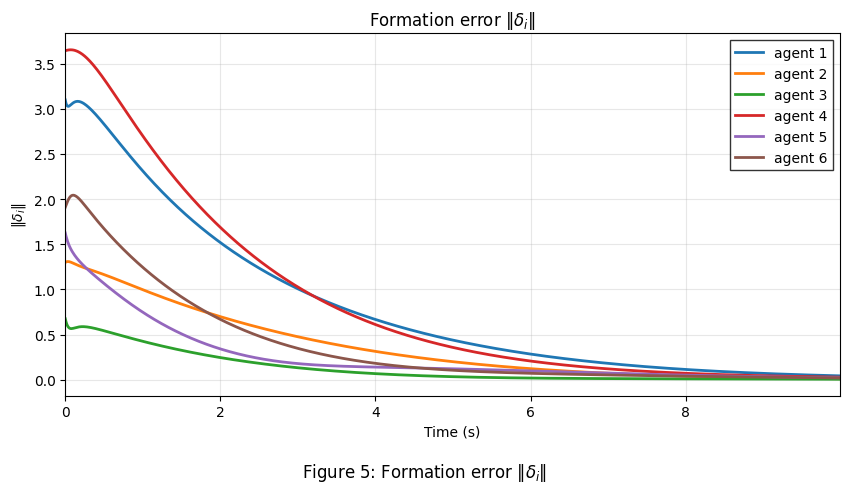

In [7]:
dt = 0.01
norms = compute_delta_norms(agents, leader, use_pos_only=False)  # dùng 4D error
# hoặc use_pos_only=True nếu paper chỉ xét position error

plot_formation_error(
    norms,
    dt=dt,
    caption=r"Figure 5: Formation error $\|\delta_i\|$"
)

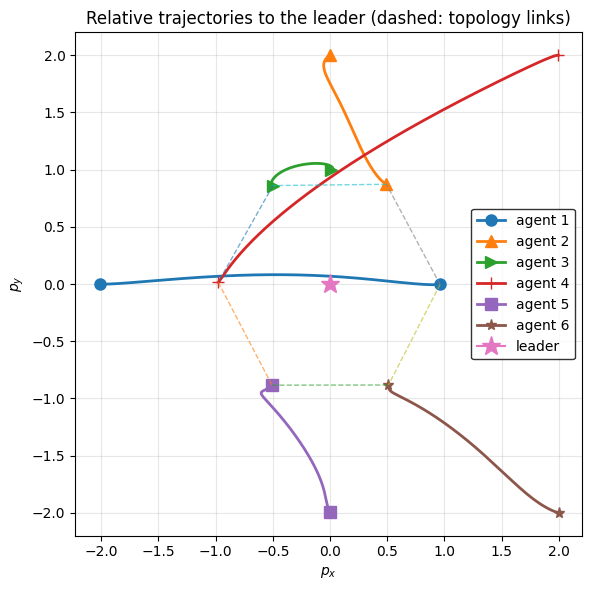

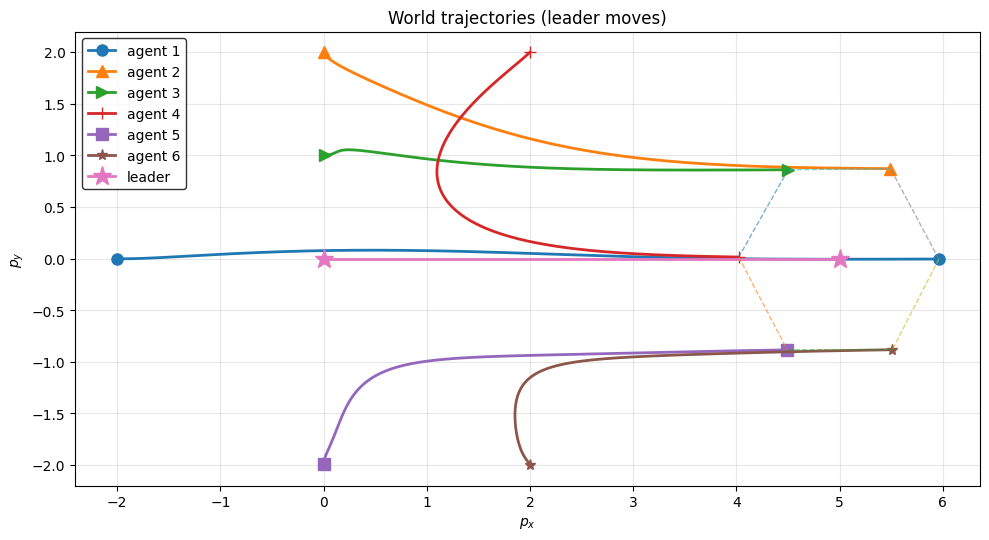

In [8]:
plot_relative_trajectories(agents, leader, topo, show_topology_at="final")
plot_world_trajectories(agents, leader, topo, topology_at="final")

for ag in agents:
    ag.clear_history

In [16]:
from utils import ErrorTracker, compute_delta_norms
from utils import plot_formation_error, plot_relative_trajectories, plot_world_trajectories
from safety_formation.control_law.cbf import CentralizedCBF

controller = CentralizedFormationControl(K_matrix=K, K_prime_matrix=K_prime)
safety_filter = CentralizedCBF(gamma= 0.2, safety_dis= 0.5 )
tracker = ErrorTracker()

dt = 0.1
T = 10.0
steps = int(T / dt)

for k in range(steps):

     # ---- Controller (centralized) ----
    U = controller.compute_nominal(
        all_agents=agents,
        topology=topo,
        leader_state=leader.state
    )  # shape (N,2)
    
    U_safe = safety_filter.compute_safe_control(
        all_agents=agents, 
        topology=topo, 
        u_nom= U
    )
    
    
    print(f"U_safe {U_safe}")
    
    # ---- Apply control to each follower ----
    for i, ag in enumerate(agents):
        ag.update_physics(U_safe[i], dt)

    # ---- Leader dynamics (optional) ----
    # Ví dụ leader constant velocity:
    leader.update_physics([0, 0], dt)

    # ---- Track error ----
    tracker.step(agents, leader.state)

U_safe [[-7.10360823e-05  9.55101889e-06]
 [-3.48712816e-06  2.86495857e-05]
 [ 5.63178333e-06  1.81608460e-06]
 [ 4.92074868e-05  5.69806759e-05]
 [-1.03210977e-05 -4.33197452e-06]
 [ 3.22299776e-05 -2.63478095e-06]]
U_safe [[-6.83253715e-05  9.26208171e-06]
 [-3.82878881e-06  2.74767167e-05]
 [ 4.84541806e-06  1.80519518e-06]
 [ 4.60876488e-05  5.46028221e-05]
 [-1.08771512e-05 -3.88068401e-06]
 [ 2.99928609e-05 -2.24855989e-06]]
U_safe [[-6.57187426e-05  8.95984361e-06]
 [-4.13716702e-06  2.63288051e-05]
 [ 4.11461468e-06  1.77176418e-06]
 [ 4.31430458e-05  5.22913925e-05]
 [-1.13690577e-05 -3.49806303e-06]
 [ 2.78856727e-05 -1.92416912e-06]]
U_safe [[-6.32111531e-05  8.64685799e-06]
 [-4.41323988e-06  2.52068509e-05]
 [ 3.43712180e-06  1.71860794e-06]
 [ 4.03660839e-05  5.00464669e-05]
 [-1.17993437e-05 -3.17742208e-06]
 [ 2.59031207e-05 -1.65557318e-06]]
U_safe [[-6.07978990e-05  8.32548401e-06]
 [-4.65807257e-06  2.41117238e-05]
 [ 2.81068314e-06  1.64834380e-06]
 [ 3.77493445e-0

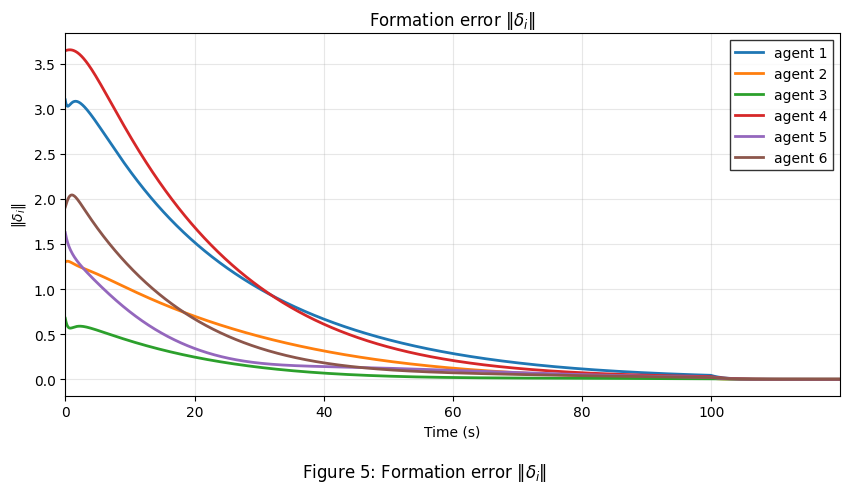

In [17]:
dt = 0.1
norms = compute_delta_norms(agents, leader, use_pos_only=False)  # dùng 4D error
# hoặc use_pos_only=True nếu paper chỉ xét position error

plot_formation_error(
    norms,
    dt=dt,
    caption=r"Figure 5: Formation error $\|\delta_i\|$"
)

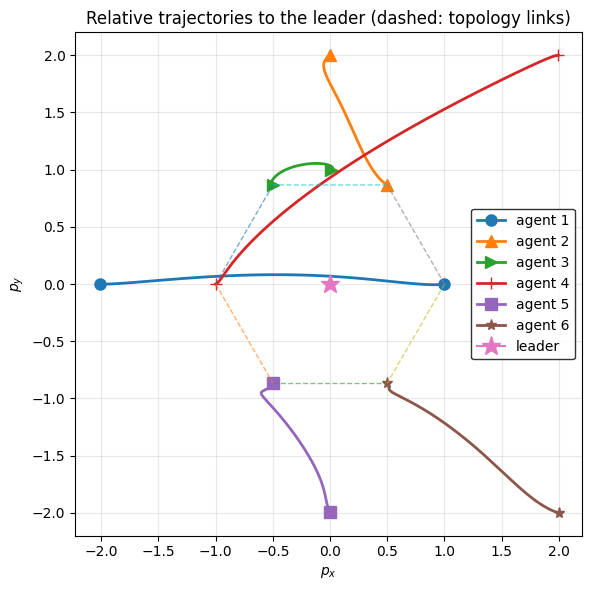

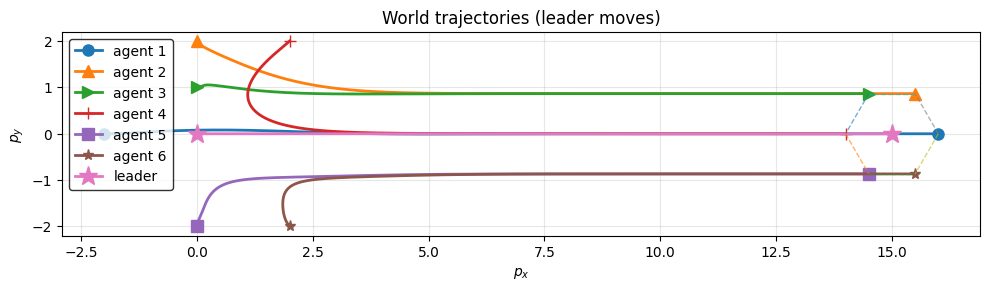

In [18]:
plot_relative_trajectories(agents, leader, topo, show_topology_at="final")
plot_world_trajectories(agents, leader, topo, topology_at="final")

for ag in agents:
    ag.clear_history

In [12]:
from qpsolvers import solve_qp

P = 2 * np.eye(2)
q = np.array([-5.0, -7.0])

G = np.array([[4.0, 1.0], [1.0, 4.0], [-1.0, 0.0], [0.0, -1.0]])
h = np.array([20.0, 20.0, 0.0, 0.0])

sol = solve_qp(P, q, G, h, solver= "quadprog")

print(sol)

[2.5 3.5]


QP Solver failed to find a solution!


/home/hung-nguyen/Safety_Formation_Control_CBF/safety_formation/control_law/cbf/centralized_cbf.py:32: RuntimeWarning: invalid value encountered in sqrt
  term_safe_v = np.sqrt(2*(agent_i.alpha + agent_j.alpha)*(dist - self.d_min))


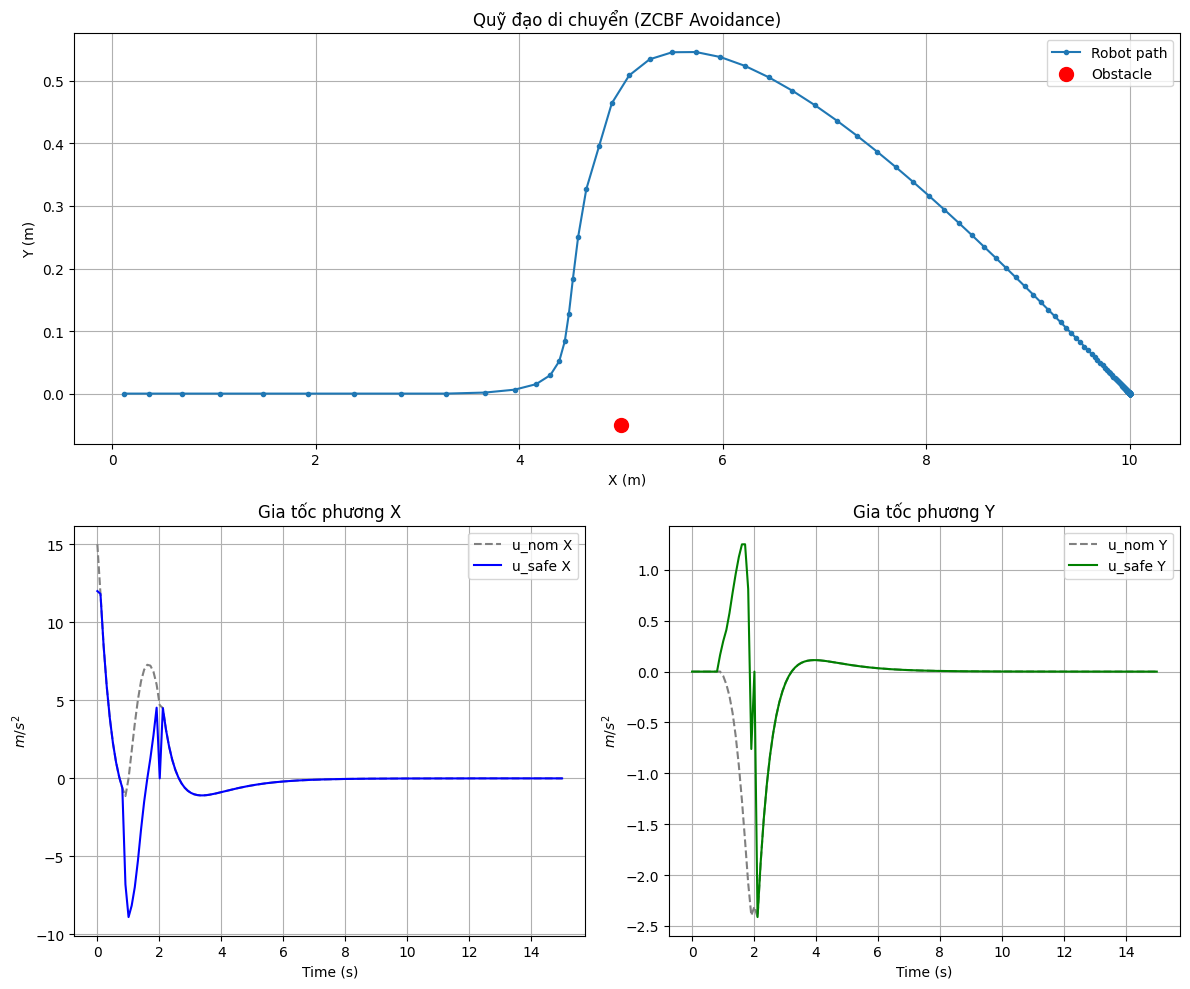

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# --- Giả sử lớp CentralizedCBF đã được định nghĩa ở trên ---

# Khởi tạo thông số
dt = 0.1
T = 15.0 # Tăng thời gian để xem robot vượt qua vật cản
steps = int(T / dt)
gamma =4 # Tăng gamma một chút để phản ứng mượt hơn
d_min = 0.5 

x_agent = np.array([0.0, 0.0, 0.0, 0.0]) 
x_obs = np.array([5.0, -0.05, 0, 0.0]) 
x_target = np.array([10.0, 0.0, 0.0, 0.0])

alpha_agent = 12.0
alpha_obs = 0.0 

history = []
u_hat_history = []
u_safe_history = []

cbf_filter = CentralizedCBF(gamma=gamma, safety_dis=d_min)

for k in range(steps):
    # 1. Tính u_nom
    # Dùng x_agent[0:2] (vị trí hiện tại) thay vì x_init để robot luôn hướng về đích
    u_hat = -1.5 * (x_agent[0:2] - x_target[0:2]) - 2.5 * x_agent[2:4]
    
    # 2. Mock Data
    class MockAgent:
        def __init__(self, state, alpha, id):
            self.state = state.reshape(4,1); self.alpha = alpha
            self.id = id; self.pos = state[0:2]; self.vel = state[2:4]
            self.gamma = gamma
    
    a1 = MockAgent(x_agent, alpha_agent, 1)
    a2 = MockAgent(x_obs, alpha_obs, 2)
    
    class MockTopo:
        adj_matrix = np.array([[0, 1], [1, 0]])
    
    # 3. Lọc qua CBF
    u_nom_all = np.array([u_hat, [0, 0]]) 
    u_safe_all = cbf_filter.compute_safe_control([a1, a2], MockTopo(), u_nom_all)
    
    if u_safe_all is not None:
        u_apply = u_safe_all[0]
    else:
        u_apply = np.array([0, 0])

    # Lưu lịch sử điều khiển
    u_hat_history.append(u_hat.copy())
    u_safe_history.append(u_apply.copy())

    # 4. Update Physics
    x_agent[2:4] += u_apply * dt
    x_agent[0:2] += x_agent[2:4] * dt
    history.append(x_agent.copy())

# --- Chuyển dữ liệu sang mảng Numpy ---
history = np.array(history)
u_hat_history = np.array(u_hat_history)
u_safe_history = np.array(u_safe_history)
time = np.linspace(0, T, steps)

# --- VẼ ĐỒ THỊ ---
fig = plt.figure(figsize=(12, 10))

# 1. Quỹ đạo di chuyển
ax1 = plt.subplot(2, 1, 1)
ax1.plot(history[:, 0], history[:, 1], '-o', markersize=3, label='Robot path')
ax1.scatter([5.0], [-0.05], color='red', s=100, label='Obstacle', zorder=5)
ax1.set_title("Quỹ đạo di chuyển (ZCBF Avoidance)")
ax1.set_xlabel("X (m)"); ax1.set_ylabel("Y (m)")
ax1.legend(); ax1.grid(True)

# 2. Tín hiệu điều khiển u_x
ax2 = plt.subplot(2, 2, 3)
ax2.plot(time, u_hat_history[:, 0], '--', color='gray', label='u_nom X')
ax2.plot(time, u_safe_history[:, 0], '-', color='blue', label='u_safe X')
ax2.set_title("Gia tốc phương X")
ax2.set_xlabel("Time (s)"); ax2.set_ylabel("$m/s^2$")
ax2.legend(); ax2.grid(True)

# 3. Tín hiệu điều khiển u_y
ax3 = plt.subplot(2, 2, 4)
ax3.plot(time, u_hat_history[:, 1], '--', color='gray', label='u_nom Y')
ax3.plot(time, u_safe_history[:, 1], '-', color='green', label='u_safe Y')
ax3.set_title("Gia tốc phương Y")
ax3.set_xlabel("Time (s)"); ax3.set_ylabel("$m/s^2$")
ax3.legend(); ax3.grid(True)

plt.tight_layout()
plt.show()

Agent 0 pos = [ 1.498e+02 -1.000e-01]
Agent 0 pos = [149.4    -0.279]
Agent 0 pos = [148.8      -0.51941]
Agent 0 pos = [148.         -0.8065439]
Agent 0 pos = [147.          -1.12818558]
Agent 0 pos = [145.8         -1.47421707]
Agent 0 pos = [144.4         -1.83630009]
Agent 0 pos = [142.8         -2.20760351]
Agent 0 pos = [141.         -2.5825702]
Agent 0 pos = [139.          -2.95671786]
Agent 0 pos = [136.8         -3.32646881]
Agent 0 pos = [134.4         -3.68900487]
Agent 0 pos = [131.8         -4.04214368]
Agent 0 pos = [129.          -4.38423329]
Agent 0 pos = [126.          -4.71406264]
Agent 0 pos = [122.8        -5.0307855]
Agent 0 pos = [119.4         -5.33385593]
Agent 0 pos = [115.8         -5.62297371]
Agent 0 pos = [112.         -5.8980382]
Agent 0 pos = [108.          -6.15910942]
Agent 0 pos = [103.8         -6.40637529]
Agent 0 pos = [99.4        -6.64012424]
Agent 0 pos = [94.99617529 -6.67387318]
Agent 0 pos = [90.79235058 -6.73230909]
Agent 0 pos = [86.78852587

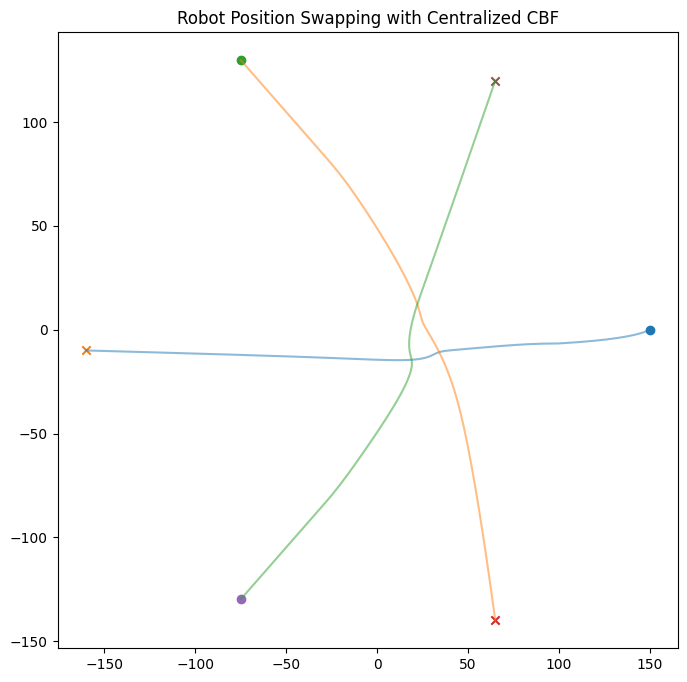

In [14]:
import numpy as np

# --- Cấu hình mô phỏng ---
N = 3           # 20 robot như trong bài báo
R_circle = 150   # Bán kính vòng tròn
dt = 0.1
T_max = 100
gamma = 0.1
d_min = 9.0      # Ds = 10
k1, k2 = 1.0, 2.0 # Hệ số PD controller

# --- Khởi tạo trạng thái ---
agents_list = []
class AgentObj:
    def __init__(self, id, pos, target):
        self.id = id
        self.pos = pos
        self.vel = np.zeros(2)
        self.target = target
        self.alpha = 20.0 # Gia tốc tối đa
        self.gamma = gamma

for i in range(N):
    angle = 2 * np.pi * i / N
    # Vị trí ban đầu trên vòng tròn
    pos = np.array([R_circle * np.cos(angle), R_circle * np.sin(angle)])
    # Đích đến ở phía đối diện
    target = -pos -10
    agents_list.append(AgentObj(i, pos, target))

# Giả lập Topology (Tất cả thấy nhau - Fully Connected cho Centralized)
class FullTopology:
    adj_matrix = np.ones((N, N)) - np.eye(N)

cbf_filter = CentralizedCBF(gamma=gamma, safety_dis=d_min)

# --- Vòng lặp mô phỏng ---
history = [[] for _ in range(N)]

for t in range(int(T_max/dt)):
    # 1. Tính u_nom cho toàn bộ N robot (PD Control)
    u_nom_all = []
    for ag in agents_list:
        u_i = -k1 * (ag.pos - ag.target) - k2 * ag.vel
        u_nom_all.append(u_i)
    u_nom_all = np.array(u_nom_all)

    # 2. Lọc qua Centralized CBF
    u_safe_all = cbf_filter.compute_safe_control(agents_list, FullTopology(), u_nom_all)
    
    if u_safe_all is None: break

    # 3. Cập nhật vật lý
    for i, ag in enumerate(agents_list):
        ag.vel += u_safe_all[i] * dt
        ag.pos += ag.vel * dt
        history[i].append(ag.pos.copy())
    print(f"Agent 0 pos = {agents_list[0].pos}")

# --- Vẽ quỹ đạo (Sử dụng Matplotlib để xem kết quả giống Fig 3) ---
import matplotlib.pyplot as plt
plt.figure(figsize=(8,8))
for i in range(N):
    traj = np.array(history[i])
    plt.plot(traj[:,0], traj[:,1], alpha=0.5)
    plt.scatter(traj[0,0], traj[0,1], marker='o') # Start
    plt.scatter(traj[-1,0], traj[-1,1], marker='x') # End
plt.title("Robot Position Swapping with Centralized CBF")
plt.show()

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FFMpegWriter, FuncAnimation

# --- Cấu hình mô phỏng ---
N = 3           # 20 robot như trong bài báo
R_circle = 150   # Bán kính vòng tròn
dt = 0.1
T_max = 16
gamma = 5
d_min = 9.0      # Ds = 10
k1, k2 = 1.0, 2.0 # Hệ số PD controller

# 2. Định nghĩa Class (Đảm bảo dùng float)
class AgentObj:
    def __init__(self, id, pos, target):
        self.id = id
        self.pos = np.array(pos, dtype=float)
        self.vel = np.zeros(2, dtype=float)
        self.target = np.array(target, dtype=float)
        self.alpha = 20.0 # Gia tốc tối đa

# 3. KHỞI TẠO LẠI TRẠNG THÁI (Bước quan trọng nhất)
agents_list = []
history = [[] for _ in range(N)]

for i in range(N):
    angle = 2 * np.pi * i / N
    # Vị trí bắt đầu trên vòng tròn
    pos = np.array([R_circle * np.cos(angle), R_circle * np.sin(angle)], dtype=float)
    # Đích đến đối diện (Swap vị trí)
    target = -pos - 10
    agents_list.append(AgentObj(i, pos, target))

# 4. Thiết lập Figure cho Animation
fig, ax = plt.subplots(figsize=(8, 8))
ax.set_xlim(-R_circle - 50, R_circle + 50)
ax.set_ylim(-R_circle - 50, R_circle + 50)
ax.set_aspect("equal")
ax.grid(True)
ax.set_title("Robot Swapping - CBF Simulation")

# Vẽ các đích đến (X đỏ)
for ag in agents_list:
    ax.scatter(ag.target[0], ag.target[1], marker="x", color="red", s=100)

# Khởi tạo các đối tượng đồ họa
points = [ax.plot([], [], "o", ms=10)[0] for _ in range(N)]
trails = [ax.plot([], [], alpha=0.3, lw=1.5)[0] for _ in range(N)]
info_text = ax.text(0.02, 0.95, "", transform=ax.transAxes)

# 5. Hàm cập nhật (Update) cho từng Frame
def update(frame):
    global agents_list, history
    
    # Tính toán điều khiển nominal (u_nom)
    u_nom_all = []
    for ag in agents_list:
        u_i = -k1 * (ag.pos - ag.target) - k2 * ag.vel
        u_nom_all.append(u_i)
    u_nom_all = np.array(u_nom_all)

    # Tính toán CBF (Sử dụng bộ lọc của bạn)
    u_safe_all = cbf_filter.compute_safe_control(agents_list, FullTopology(), u_nom_all)
    # u_safe_all = u_nom_all # Tạm thời dùng u_nom để test di chuyển

    # Cập nhật vật lý (Tích phân Euler)
    for i in range(N):
        agents_list[i].vel += u_safe_all[i] * dt
        agents_list[i].pos += agents_list[i].vel * dt
        
        # Cập nhật dữ liệu vẽ
        history[i].append(agents_list[i].pos.copy())
        traj = np.array(history[i])
        
        points[i].set_data([agents_list[i].pos[0]], [agents_list[i].pos[1]])
        trails[i].set_data(traj[:, 0], traj[:, 1])

    # Log debug mỗi 50 frame
    if frame % 50 == 0:
        print(f"Frame {frame}: Agent 0 đang ở {agents_list[0].pos}")

    info_text.set_text(f"Time: {frame*dt:.1f}s")
    return points + trails + [info_text]

# 6. Tiến hành Render và Lưu file
print("Bắt đầu quá trình lưu video MP4...")
total_frames = int(T_max / dt)
ani = FuncAnimation(fig, update, frames=total_frames, blit=True)

# Cấu hình Writer (Yêu cầu ffmpeg đã cài đặt)
try:
    writer = FFMpegWriter(fps=int(1/dt), bitrate=2000)
    ani.save("robot_cbf_simulation.mp4", writer=writer)
    print("Xong! File 'robot_cbf_simulation.mp4' đã được tạo.")
except Exception as e:
    print(f"Lỗi khi lưu video: {e}")

plt.close(fig)

Bắt đầu quá trình lưu video MP4...
Frame 0: Agent 0 đang ở [ 1.498e+02 -1.000e-01]
Frame 0: Agent 0 đang ở [149.4    -0.279]
Frame 0: Agent 0 đang ở [148.8      -0.51941]
Frame 0: Agent 0 đang ở [148.         -0.8065439]
Frame 50: Agent 0 đang ở [  9.58577759 -14.67641676]
Frame 100: Agent 0 đang ở [-151.56814954  -10.20676937]
Frame 150: Agent 0 đang ở [-159.80649674  -10.00473938]
Xong! File 'robot_cbf_simulation.mp4' đã được tạo.
